In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [31]:
df = pd.read_csv("./data/pns_raw.csv")
df

,Unidade da Federação,Estrato,UPA,Número de ordem do domicílio na PNS,Tipo da entrevista,Ano de referência,Total de moradores,Tipo de situação censitária,Tipo de área,Seleção do morador de 15 anos ou mais para responder o questionário individual,...,Condição em relação à força de trabalho na semana de referência para pessoas de 14 anos ou mais de idade,Condição de ocupação na semana de referência para pessoas de 14 anos ou mais de idade,Grupamentos de atividade do trabalho principal da semana de referência para pessoas de 14 anos ou mais de idade,"Rendimento domiciliar \n(exclusive o rendimento das pessoas cuja condição na unidade domiciliar era pensionista, empregado doméstico ou parente do empregado doméstico)","Rendimento domiciliar per capita\n(exclusive o rendimento das pessoas cuja condição na unidade domiciliar era pensionista, empregado doméstico ou parente do empregado doméstico)","Faixa de rendimento domiciliar per capita (exclusive o rendimento das pessoas cuja condição na unidade domiciliar era pensionista, empregado doméstico ou parente do empregado doméstico)",Idade em meses das crianças nascidas no período de referência do Módulo L,Faixa de tempo gasto por dia no deslocamento casa-trabalho pelas pessoas ocupadas que se deslocavam para o trabalho,Tipo de cigarro industrializado comprado,Método contraceptivo mais eficaz que faz uso
0,11,1110011,110000016,1,1,2019,6.0,1,1,1.0,...,1.0,6.0,2098.0,350.0,2.0,NaN,NaN,NaN,NaN,20220504
1,11,1110011,110000016,1,1,2019,6.0,1,1,0.0,...,NaN,NaN,2098.0,350.0,2.0,NaN,NaN,NaN,NaN,20220504
2,11,1110011,110000016,1,1,2019,6.0,1,1,0.0,...,1.0,4.0,2098.0,350.0,2.0,NaN,NaN,NaN,NaN,20220504
3,11,1110011,110000016,1,1,2019,6.0,1,1,9.0,...,NaN,NaN,2098.0,350.0,2.0,NaN,NaN,NaN,NaN,20220504
4,11,1110011,110000016,1,1,2019,6.0,1,1,9.0,...,NaN,NaN,2098.0,350.0,2.0,NaN,NaN,NaN,NaN,20220504
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
293721,53,5310220,530044434,14,1,2019,4.0,2,1,0.0,...,1.0,1.0,13390.0,3348.0,6.0,NaN,NaN,NaN,NaN,20220504
293722,53,5310220,530044434,14,1,2019,4.0,2,1,1.0,...,NaN,NaN,13390.0,3348.0,6.0,NaN,NaN,NaN,NaN,20220504
293723,53,5310220,530044434,14,1,2019,4.0,2,1,0.0,...,1.0,7.0,13390.0,3348.0,6.0,NaN,NaN,NaN,NaN,20220504
293724,53,5310220,530044434,14,1,2019,4.0,2,1,9.0,...,NaN,NaN,13390.0,3348.0,6.0,NaN,NaN,NaN,NaN,20220504


In [34]:
# Removendo linhas sem valore da variavel target
target = "Em geral, como o(a) Sr(a) avalia a sua saúde"
df_new = df.dropna(subset=[target])
print(f"Shape removendo linhas sem a variavel target: {df.shape, df_new.shape}")


# Removendo colunas com 80% de valores nulos
limite = 0.8
proporcao_nulos = df_new.isna().mean()
colunas_para_deletar = proporcao_nulos[proporcao_nulos >= limite].index
df_new = df_new.drop(columns=colunas_para_deletar)
print(f"Shape removendo colunas com >=80% de NaN {df_new.shape}")


# Removendo linhas com 80% de valores nulos
percentual_nans_linhas = df_new.isna().mean(axis=1) * 100
linhas_80pc_nans = df_new.index[percentual_nans_linhas >= 80].tolist()
print("Linhas com ≥80% de NaN:", len(linhas_80pc_nans))


Shape removendo linhas sem a variavel target: ((293726, 1088), (90846, 1088))
Shape removendo colunas com >=80% de NaN (90846, 490)
Linhas com ≥80% de NaN: 0


In [35]:
df_new.shape

(90846, 490)

In [44]:
target_col = "Em geral, como o(a) Sr(a) avalia a sua saúde"


target_values = df_new[target_col]
target_values[0]

np.float64(3.0)

In [49]:
target_col = "Em geral, como o(a) Sr(a) avalia a sua saúde"


target_values = df_new[target_col]
every_values = {"1": 0, "2": 0, "3": 0, "4":0, "5": 0}

target_values

for each in target_values:
  each = str(np.int64(each))
  every_values[each] += 1
  
  
every_values["Muito Boa"] = every_values.pop("1")
every_values["Boa"] = every_values.pop("2")
every_values["Regular"] = every_values.pop("3")
every_values["Ruim"] = every_values.pop("4")
every_values["Muito Ruim"] = every_values.pop("5")

every_values

{'Muito Boa': 11995,
 'Boa': 44827,
 'Regular': 27916,
 'Ruim': 4935,
 'Muito Ruim': 1173}

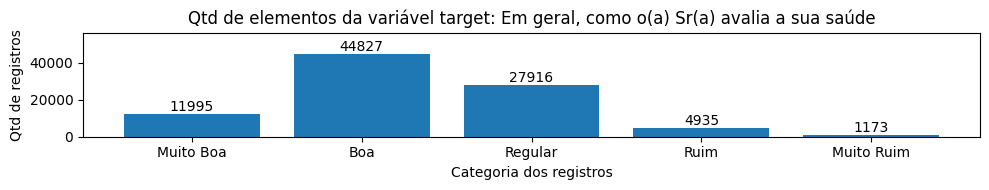

In [51]:
plt.figure(figsize=(10, 2))

labels = list(every_values.keys())
values = list(map(int, every_values.values()))

bars = plt.bar(labels, values)

plt.title(f"Qtd de elementos da variável target: {target_col}")
plt.ylabel("Qtd de registros")
plt.xlabel("Categoria dos registros")

plt.ylim(0, max(values) * 1.25)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height}',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


Verificando a qtd de colunas com 100% dos dados

In [7]:
qtd_colunas_completas = df_new.notna().all().sum()
print(qtd_colunas_completas)

209


In [8]:
colunas_completas = df_new.columns[df_new.notna().all()]

Colunas Escolhidas

In [9]:
colunas_final = [
    #Target
    "Em geral, como o(a) Sr(a) avalia a sua saúde",
    
    
    # Sociodemográfico
    "Idade do morador na data de referência",
    "Sexo",
    "Cor ou raça",
    "Qual é o estado civil de ___?",
    "Nível de instrução mais elevado alcançado (pessoas de 5 anos ou mais de idade) padronizado para o Ensino Fundamental -  SISTEMA DE 9 ANOS",

    # Socioeconômico
    "Total de moradores",
    "Quantos cômodos têm este domicílio",
    "Quantos banheiros (com chuveiro ou banheira e vaso sanitário ou privada) de uso exclusivo dos moradores existem neste domicílio, inclusive os localizados no terreno ou propriedade",
    "Neste domicílio existe automóvel",
    "Neste domicílio existe computador (considere inclusive os portáteis, tais como: laptop, notebook ou netbook)?",
    "Algum morador tem acesso à Internet no domicílio por meio de computador, tablet, telefone móvel celular, televisão ou outro equipamento?",

    # Saúde mental
    "Nas duas últimas semanas, com que frequência o(a) Sr(a) teve problemas no sono, como dificuldade para adormecer, acordar frequentemente à noite ou dormir mais do que de costume?",
    "Nas duas últimas semanas, com que frequência o(a) Sr(a) teve problemas por não se sentir descansado(a) e disposto(a) durante o dia, sentindo-se cansado(a), sem ter energia?",
    "Nas duas últimas semanas, com que frequência o(a) Sr(a) teve pouco interesse ou não senitiu prazer em fazer as coisas?",
    "Nas duas últimas semanas, com que frequência o(a) Sr(a) se sentiu deprimido(a), “pra baixo” ou sem perspectiva?",

    # Doenças
    # "Algum médico já deu o diagnóstico de alguma doença crônica, física ou mental, ou doença de longa duração (de mais de 6 meses de duração) a ___", (Variavel Direta)
    "Em geral, em que grau a depressão limita as suas atividades habituais (tais como trabalhar, realizar afazeres domésticos, etc.)?",
    "Em geral, em que grau essa doença mental limita as suas atividades habituais (tais como trabalhar, realizar afazeres domésticos etc.)?",
    "Em geral, em que grau o DORT limita as suas atividades habituais (tais como trabalhar, realizar afazeres domésticos etc.)?",

    # Estilo de vida
    "Nos últimos três meses, o(a) Sr(a) praticou algum tipo de exercício físico ou esporte?",
    "Em média, quantas horas por dia o(a) Sr(a) costuma ficar assistindo televisão?",
    "Atualmente, o(a) Sr(a) fuma algum produto do tabaco?",
    "Com que frequência o(a) Sr(a) costuma consumir alguma bebida alcoólica?",

    # Apoio social
    "Com quantos familiares ou parentes ___ pode contar em momentos bons ou ruins",
    "Com quantos amigos próximos ___ pode contar em momentos bons ou ruins (Sem considerar os familiares ou parentes"
]

df_select = df_new[colunas_final]
df_select.isnull().any().any()

np.False_

In [10]:
df_select.columns, len(df_select.columns)

(Index(['Em geral, como o(a) Sr(a) avalia a sua saúde',
        'Idade do morador na data de referência', 'Sexo', 'Cor ou raça',
        'Qual é o estado civil de ___?',
        'Nível de instrução mais elevado alcançado (pessoas de 5 anos ou mais de idade) padronizado para o Ensino Fundamental -  SISTEMA DE 9 ANOS',
        'Total de moradores', 'Quantos cômodos têm este domicílio',
        'Quantos banheiros (com chuveiro ou banheira e vaso sanitário ou privada) de uso exclusivo dos moradores existem neste domicílio, inclusive os localizados no terreno ou propriedade',
        'Neste domicílio existe automóvel',
        'Neste domicílio existe computador (considere inclusive os portáteis, tais como: laptop, notebook ou netbook)?',
        'Algum morador tem acesso à Internet no domicílio por meio de computador, tablet, telefone móvel celular, televisão ou outro equipamento?',
        'Nas duas últimas semanas, com que frequência o(a) Sr(a) teve problemas no sono, como dificuldade par

In [11]:
rename_dict = {
    'Em geral, como o(a) Sr(a) avalia a sua saúde': 'Autoavaliacao_Saude',
    'Idade do morador na data de referência': 'Idade',
    'Sexo': 'Sexo',
    'Cor ou raça': 'Cor_Raca',
    'Qual é o estado civil de ___?': 'Estado_Civil',
    'Nível de instrução mais elevado alcançado (pessoas de 5 anos ou mais de idade) padronizado para o Ensino Fundamental -  SISTEMA DE 9 ANOS': 'Nivel_Instrucao',
    'Total de moradores': 'Total_Moradores',
    'Quantos cômodos têm este domicílio': 'Qtd_Comodos',
    'Quantos banheiros (com chuveiro ou banheira e vaso sanitário ou privada) de uso exclusivo dos moradores existem neste domicílio, inclusive os localizados no terreno ou propriedade': 'Qtd_Banheiros',
    'Neste domicílio existe automóvel': 'Possui_Automovel',
    'Neste domicílio existe computador (considere inclusive os portáteis, tais como: laptop, notebook ou netbook)?': 'Possui_Computador',
    'Algum morador tem acesso à Internet no domicílio por meio de computador, tablet, telefone móvel celular, televisão ou outro equipamento?': 'Acesso_Internet',
    'Nas duas últimas semanas, com que frequência o(a) Sr(a) teve problemas no sono, como dificuldade para adormecer, acordar frequentemente à noite ou dormir mais do que de costume?': 'Freq_Problemas_Sono',
    'Nas duas últimas semanas, com que frequência o(a) Sr(a) teve problemas por não se sentir descansado(a) e disposto(a) durante o dia, sentindo-se cansado(a), sem ter energia?': 'Freq_Cansaco',
    'Nas duas últimas semanas, com que frequência o(a) Sr(a) teve pouco interesse ou não senitiu prazer em fazer as coisas?': 'Freq_Anedonia',
    'Nas duas últimas semanas, com que frequência o(a) Sr(a) se sentiu deprimido(a), “pra baixo” ou sem perspectiva?': 'Freq_Depressao',
    # 'Algum médico já deu o diagnóstico de alguma doença crônica, física ou mental, ou doença de longa duração (de mais de 6 meses de duração) a ___': 'Diagnostico_Doenca_Cronica',
    'Em geral, em que grau a depressão limita as suas atividades habituais (tais como trabalhar, realizar afazeres domésticos, etc.)?': 'Grau_Limite_Depressao',
    'Em geral, em que grau essa doença mental limita as suas atividades habituais (tais como trabalhar, realizar afazeres domésticos etc.)?': 'Grau_Limite_Doenca_Mental',
    'Em geral, em que grau o DORT limita as suas atividades habituais (tais como trabalhar, realizar afazeres domésticos etc.)?': 'Grau_Limite_DORT',
    'Nos últimos três meses, o(a) Sr(a) praticou algum tipo de exercício físico ou esporte?': 'Pratica_Exercicio',
    'Em média, quantas horas por dia o(a) Sr(a) costuma ficar assistindo televisão?': 'Horas_TV',
    'Atualmente, o(a) Sr(a) fuma algum produto do tabaco?': 'Fuma',
    'Com que frequência o(a) Sr(a) costuma consumir alguma bebida alcoólica?': 'Freq_Alcool',
    'Com quantos familiares ou parentes ___ pode contar em momentos bons ou ruins': 'Apoio_Familiar',
    'Com quantos amigos próximos ___ pode contar em momentos bons ou ruins (Sem considerar os familiares ou parentes': 'Apoio_Amigos'
}

df_select = df_select.rename(columns=rename_dict)


In [12]:
df_select.to_csv("./data/df_final_janeiro_22.csv", index=False)